Estatísticas Descritivas:
             age     weight     height        bmi     futime       days  \
count  400123.00  400123.00  400123.00  400123.00  400123.00  400123.00   
mean       58.87      89.33     168.69      31.36    2686.83    -606.92   
std        13.25      20.72       9.72       6.67    1595.76    2415.95   
min        18.00      33.40     123.00       9.21       7.00   -7651.00   
25%        50.00      75.90     162.00      26.92    1385.00   -2259.00   
50%        59.00      89.33     168.69      31.36    2483.00    -530.00   
75%        68.00      99.50     175.00      34.13    3643.00     987.00   
max        98.00     181.70     215.00      84.40    7245.00    7187.00   

           value  
count  400123.00  
mean       63.77  
std        48.46  
min         0.00  
25%        40.00  
50%        51.00  
75%        72.00  
max     13682.00  
Correlação entre variáveis:
         age  weight  height   bmi  futime  days  value
age     1.00   -0.18   -0.17 -0.11   -0.24 

<Figure size 1000x800 with 0 Axes>

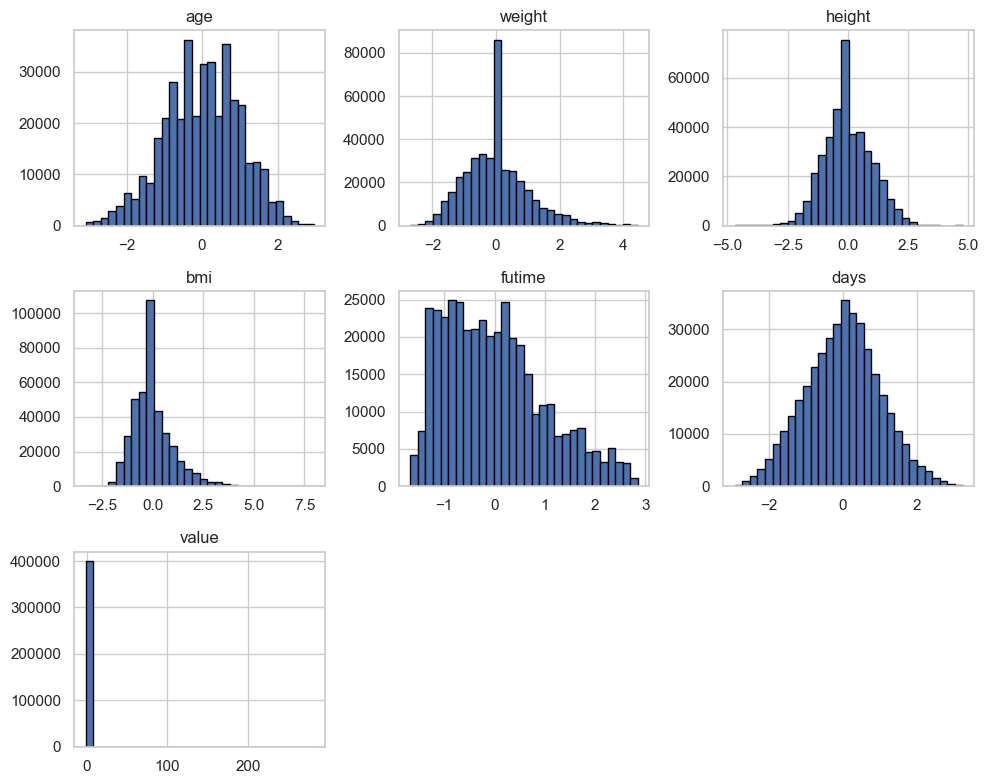

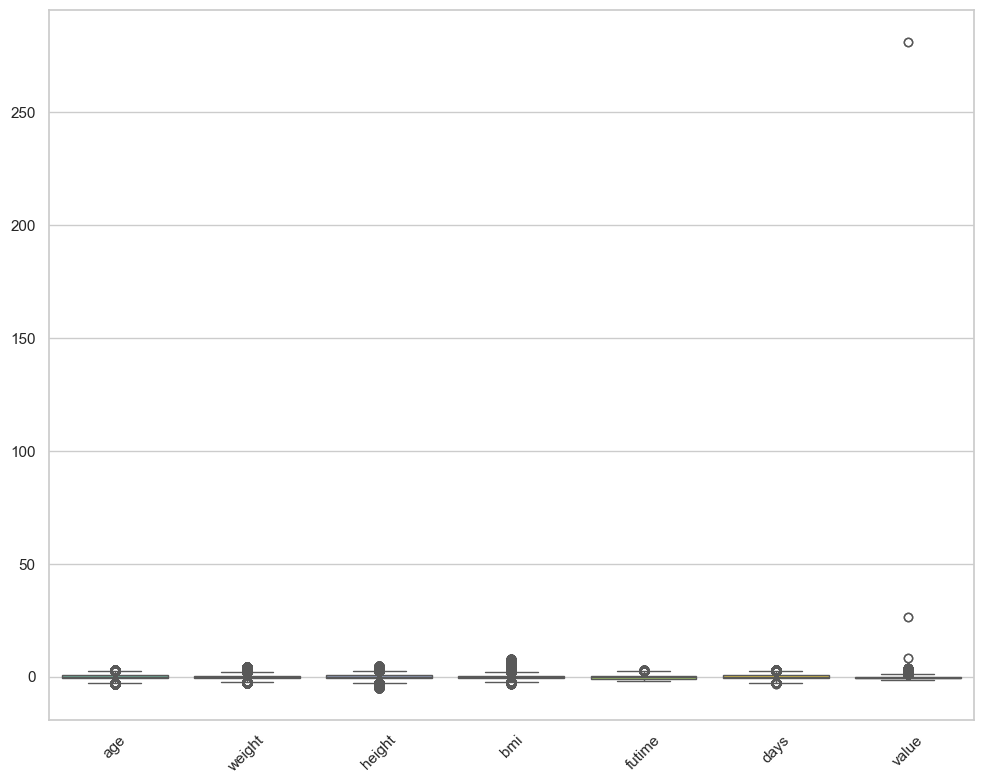

<Figure size 1000x800 with 0 Axes>

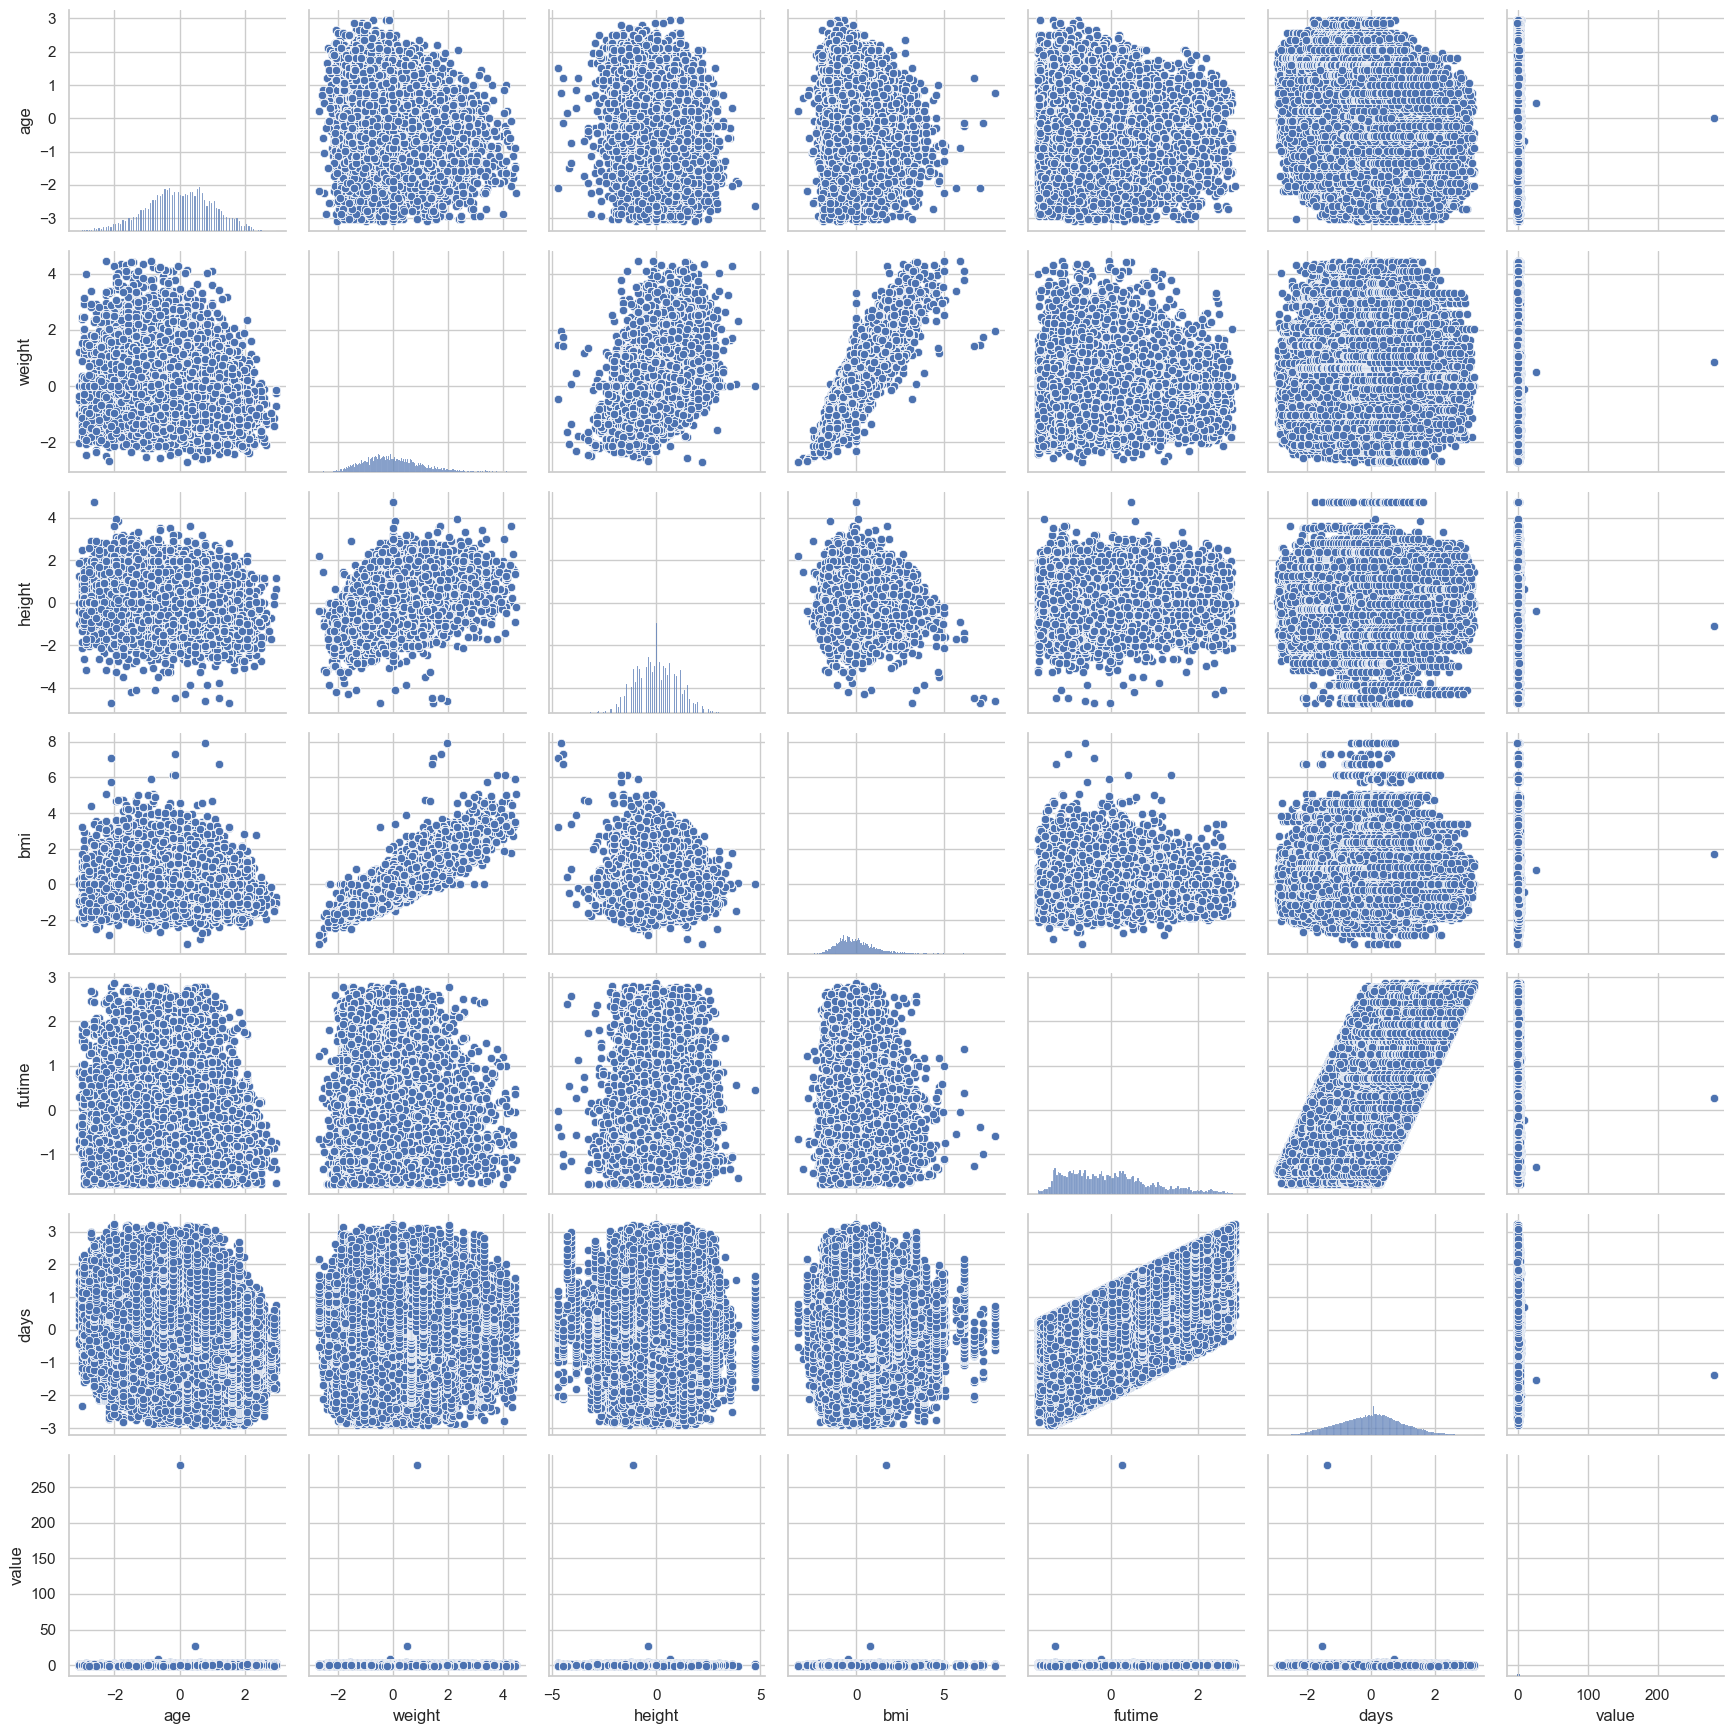

In [1]:
import os
import pandas as pd
import boto3
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Carregar variáveis de ambiente do arquivo .env
load_dotenv()

# Obter as credenciais do MinIO do arquivo .env
minio_url = os.getenv('MINIO_ENDPOINT')
minio_access_key = os.getenv('MINIO_ACCESS_KEY')
minio_secret_key = os.getenv('MINIO_SECRET_KEY')
bucket_name = "bronze"

# Criar cliente MinIO
s3_client = boto3.client('s3',
                         endpoint_url=f'http://{minio_url}',
                         aws_access_key_id=minio_access_key,
                         aws_secret_access_key=minio_secret_key,
                         config=boto3.session.Config(signature_version='s3v4'))

# Baixar o arquivo Parquet do bucket bronze no MinIO
parquet_path = "nafld_merged.parquet"
s3_client.download_file(bucket_name, parquet_path, parquet_path)

# Carregar o arquivo Parquet
df = pd.read_parquet(parquet_path)

# Selecionar colunas úteis para análise
cols_to_analyze = ['age', 'weight', 'height', 'bmi', 'futime', 'days', 'value']

# Filtrar e normalizar dados para visualizações
df_filtered = df[cols_to_analyze]
scaler = StandardScaler()
df_normalized = pd.DataFrame(scaler.fit_transform(df_filtered), columns=cols_to_analyze)

# Análise Descritiva com valores reais
print("Estatísticas Descritivas:")
stats_real = df_filtered.describe().round(2)
print(stats_real)

# Correlações com valores reais
print("Correlação entre variáveis:")
correlations_real = df_filtered.corr().round(2)
print(correlations_real)

# Ajustar o tamanho da fonte e espaçamento dos gráficos
sns.set(style="whitegrid")

# Visualizações - Histogramas (valores normalizados)
plt.figure(figsize=(10, 8))
df_normalized.hist(bins=30, edgecolor='black', figsize=(10, 8))
plt.tight_layout()
plt.show()

# Box plots para variáveis selecionadas (valores normalizados)
plt.figure(figsize=(10, 8))
sns.boxplot(data=df_normalized, palette="Set2")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Scatter plot das variáveis selecionadas (valores normalizados)
plt.figure(figsize=(10, 8))
sns.pairplot(df_normalized)
plt.tight_layout()
plt.show()